# Pandas Tutorial


---



This notebook serves as an introduction to the essential data structures offered by the **Pandas** library, a cornerstone tool in the Python data science ecosystem.

Built on top of NumPy, Pandas provides a highly efficient and flexible implementation of **DataFrames**—two-dimensional, labeled data structures that support heterogeneous data types and gracefully handle missing values. These DataFrames enable powerful data manipulation capabilities through intuitive and high-level operations.

Throughout this notebook, we will use the standard alias `pd` when importing Pandas.


In [2]:
import pandas as pd
import numpy as np

## Pandas Series


A Pandas `Series` is a one-dimensional array of indexed data.

In [3]:
data = pd.Series([0.25, 0.5, 0.75, 1.0])
data

0    0.25
1    0.50
2    0.75
3    1.00
dtype: float64

The contents can be accessed in the same way as for NumPy arrays, to the difference that when more than one value is selected, the type remains a Pandas ``Series``.

In [4]:
print(data[0],type(data[0]))

0.25 <class 'numpy.float64'>


In [5]:
print(data[2:],type(data[2:]))

2    0.75
3    1.00
dtype: float64 <class 'pandas.core.series.Series'>


The type ``Series`` wraps both a sequence of values and a sequence of indices, which we can access with the <tt>values</tt> and <tt>index</tt> attributes.

* ``values`` are the contents of the series as a NumPy array

In [6]:
print(data.values,type(data.values))

[0.25 0.5  0.75 1.  ] <class 'numpy.ndarray'>


* ``index`` are the indices of the series

In [7]:
print(data.index,type(data.index))

RangeIndex(start=0, stop=4, step=1) <class 'pandas.core.indexes.range.RangeIndex'>


### Series Indices

The main difference between NumPy arrays and Pandas Series is the presence of this <tt>index</tt> field. By default, it is set (as in NumPy arrays) as <tt>0,1,..,size_of_the_series</tt> but a Series index can be explicitly defined. The indices may be numbers but also strings. Then, the contents of the series *have to* be accessed using these defined indices.

In [8]:
data = pd.Series([0.25, 0.5, 0.75, 1.0], index=['a', 'b', 'c', 'd'])
print(data)

a    0.25
b    0.50
c    0.75
d    1.00
dtype: float64


In [9]:
print(data['c'])

0.75


In [10]:
data = pd.Series([0.25, 0.5, 0.75, 1.0], index=[1, 3, 4, 2])
print(data)

1    0.25
3    0.50
4    0.75
2    1.00
dtype: float64


In [11]:
print(data[2])

1.0


### Series and Python Dictionaries

Pandas Series and Python Dictionaries are close semantically: mappping keys to values. However, the implementation of Pandas series is usually more efficient than dictionaries in the context of data science. Naturally, Series can be contructed from dictionaries.

In [12]:
population_dict = {'California': 38332521,
                   'Texas': 26448193,
                   'New York': 19651127,
                   'Florida': 19552860,
                   'Illinois': 12882135}
population = pd.Series(population_dict)
print(population_dict,type(population_dict))
print(population,type(population))

{'California': 38332521, 'Texas': 26448193, 'New York': 19651127, 'Florida': 19552860, 'Illinois': 12882135} <class 'dict'>
California    38332521
Texas         26448193
New York      19651127
Florida       19552860
Illinois      12882135
dtype: int64 <class 'pandas.core.series.Series'>


In [13]:
population['California']

38332521

In [14]:
population['California':'Illinois']

California    38332521
Texas         26448193
New York      19651127
Florida       19552860
Illinois      12882135
dtype: int64

## Pandas DataFrames

DataFrames is a fundamental object of Pandas that mimicks what can be found in `R` for instance. Dataframes can be seen as an array of Series: to each `index` (corresponding to an individual for instance or a line in a table), a Dataframe maps multiples values; these values corresponds to the `columns` of the DataFrame which each have a name (as a string).   


In the following example, we will construct a Dataframe from two Series with common indices.

In [19]:
area = pd.Series( {'California': 423967, 'Texas': 695662, 'New York': 141297, 'Florida': 170312, 'Illinois': 149995})
population = pd.Series({'California': 38332521, 'Texas': 26448193, 'New York': 19651127, 'Florida': 19552860, 'Illinois': 12882135})
print(area)
print("\n")
population

California    423967
Texas         695662
New York      141297
Florida       170312
Illinois      149995
dtype: int64




California    38332521
Texas         26448193
New York      19651127
Florida       19552860
Illinois      12882135
dtype: int64

In [20]:
states = pd.DataFrame({'Population': population, 'Area': area})
print(states,type(states))

            Population    Area
California    38332521  423967
Texas         26448193  695662
New York      19651127  141297
Florida       19552860  170312
Illinois      12882135  149995 <class 'pandas.core.frame.DataFrame'>


In Jupyter notebooks, DataFrames are displayed in a fancier way when the name of the dataframe is typed (instead of using <tt>print</tt>)

In [21]:
states

,Population,Area
California,38332521,423967
Texas,26448193,695662
New York,19651127,141297
Florida,19552860,170312
Illinois,12882135,149995


DataFrames have
* <tt>index</tt> that are the defined indices as in Series
* <tt>columns</tt> that are the columns names
* <tt>values</tt> that return a (2D) NumPy array with the contents

In [22]:
print(states.index)
print(states.columns)
print(states.values,type(states.values),states.values.shape)

Index(['California', 'Texas', 'New York', 'Florida', 'Illinois'], dtype='object')
Index(['Population', 'Area'], dtype='object')
[[38332521   423967]
 [26448193   695662]
 [19651127   141297]
 [19552860   170312]
 [12882135   149995]] <class 'numpy.ndarray'> (5, 2)


*Warning:*  When accessing a Dataframe, `dataframe_name[column_name]` return the corresponding column as a Series. `dataframe_name[index_name]` returns an error! We will see later how to access a specific index.

In [23]:
print(states['Area'],type(states['Area']))

California    423967
Texas         695662
New York      141297
Florida       170312
Illinois      149995
Name: Area, dtype: int64 <class 'pandas.core.series.Series'>


In [24]:
try:
    print(states['California'])
except KeyError as error:
    print("KeyError: ",error)

KeyError:  'California'


### Dataframe creation

To create DataFrames, the main methods are:
* from Series (as above)

In [25]:
print(population,type(population))
states = pd.DataFrame({'Population': population, 'Area': area})
states

California    38332521
Texas         26448193
New York      19651127
Florida       19552860
Illinois      12882135
dtype: int64 <class 'pandas.core.series.Series'>


,Population,Area
California,38332521,423967
Texas,26448193,695662
New York,19651127,141297
Florida,19552860,170312
Illinois,12882135,149995


* from NumPy arrays (the columns and indices are taken as the array's ones)

In [26]:
A = np.random.randn(5,3)
print(A,type(A))
dfA = pd.DataFrame(A)
dfA

[[-0.40215356  0.18979996 -1.49605354]
 [ 0.17895022  0.04753536  0.07226504]
 [ 1.19802824  1.20481357 -0.45476174]
 [-0.66650896  0.49384276  0.7229098 ]
 [ 1.03309959 -0.07650694  1.01853831]] <class 'numpy.ndarray'>


,0,1,2
0,-0.402154,0.189800,-1.496054
1,0.178950,0.047535,0.072265
2,1.198028,1.204814,-0.454762
3,-0.666509,0.493843,0.722910
4,1.033100,-0.076507,1.018538


* from a *list* of *dictionaries*. Be careful, each element of the list is an example (corresponding to an automatic index 0,1,...) while each key of the dictonary corresponds to a column.

In [27]:
data = [{'a': i, 'b': 2 * i} for i in range(3)]
print(data,type(data))
print(data[0],type(data[0]))

[{'a': 0, 'b': 0}, {'a': 1, 'b': 2}, {'a': 2, 'b': 4}] <class 'list'>
{'a': 0, 'b': 0} <class 'dict'>


In [28]:
df = pd.DataFrame(data)
df

,a,b
0,0,0
1,1,2
2,2,4


* from a *file* , typically a <tt>csv</tt> file (for comma separated values), eventually with the names of the columns as a first line.


    col_1_name,col_2_name,col_3_name
    col_1_v1,col_2_v1,col_3_v1
    col_1_v2,col_2_v2,col_3_v2
    ...
    
For other files types (MS Excel, libSVM, any other separator) see this [part of the doc](https://pandas.pydata.org/pandas-docs/stable/api.html#input-output)

In [99]:
!head -4 president_heights.csv # bash command to see the first 4 lines of the file
data.head(4)

'head' is not recognized as an internal or external command,
operable program or batch file.


,order,name,height(cm)
0,1,George Washington,189
1,2,John Adams,170
2,3,Thomas Jefferson,189
3,4,James Madison,163


In [95]:
data = pd.read_csv('president_heights.csv')
data

,order,name,height(cm)
0,1,George Washington,189
1,2,John Adams,170
2,3,Thomas Jefferson,189
3,4,James Madison,163
4,5,James Monroe,183
5,6,John Quincy Adams,171
6,7,Andrew Jackson,185
7,8,Martin Van Buren,168
8,9,William Henry Harrison,173
9,10,John Tyler,183


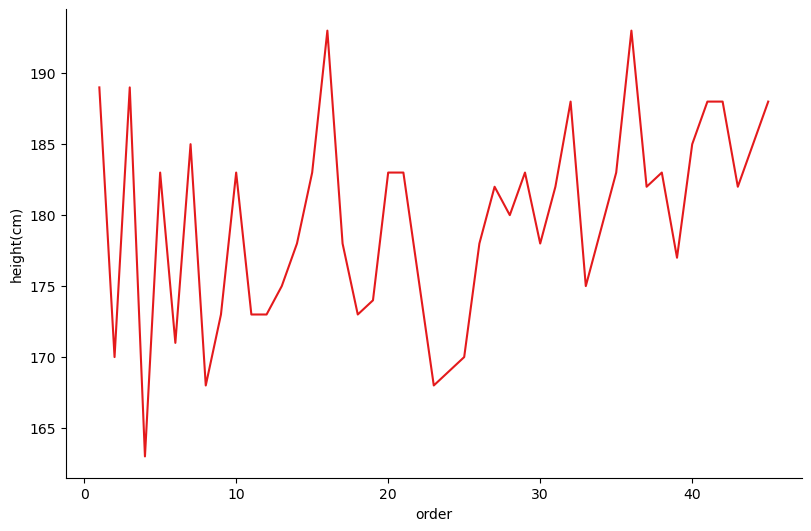

In [117]:
# @title order vs height(cm)

from matplotlib import pyplot as plt
import seaborn as sns
def _plot_series(series, series_name, series_index=0):
  palette = list(sns.palettes.mpl_palette('Set1'))
  xs = series['order']
  ys = series['height(cm)']

  plt.plot(xs, ys, label=series_name, color=palette[series_index % len(palette)])

fig, ax = plt.subplots(figsize=(8, 5.2), layout='constrained')
df_sorted = data.sort_values('order', ascending=True)
_plot_series(df_sorted, '')
sns.despine(fig=fig, ax=ax)
plt.xlabel('order')
_ = plt.ylabel('height(cm)')

### Names and Values

Notice there can be missing values in DataFrames.

In [36]:
pd.DataFrame([{'a': 1, 'b': 2}, {'b': 3, 'c': 4}])

,a,b,c
0,1.0,2,NaN
1,NaN,3,4.0


You can set indices and columns names *a posteriori*

In [37]:
dfA.columns = ['a','b','c']
dfA.index = [i**2 for i in range(1,6)  ]
dfA

,a,b,c
1,-0.402154,0.189800,-1.496054
4,0.178950,0.047535,0.072265
9,1.198028,1.204814,-0.454762
16,-0.666509,0.493843,0.722910
25,1.033100,-0.076507,1.018538


## Indexing




In [122]:
area = pd.Series( {'California': 423967, 'Texas': 695662, 'New York': 141297, 'Florida': 170312, 'Illinois': 149995})
population = pd.Series({'California': 38332521, 'Texas': 26448193, 'New York': 19651127, 'Florida': 19552860, 'Illinois': 12882135})
states = pd.DataFrame({'Population': population, 'Area': area})
states

,Population,Area
California,38332521,423967
Texas,26448193,695662
New York,19651127,141297
Florida,19552860,170312
Illinois,12882135,149995


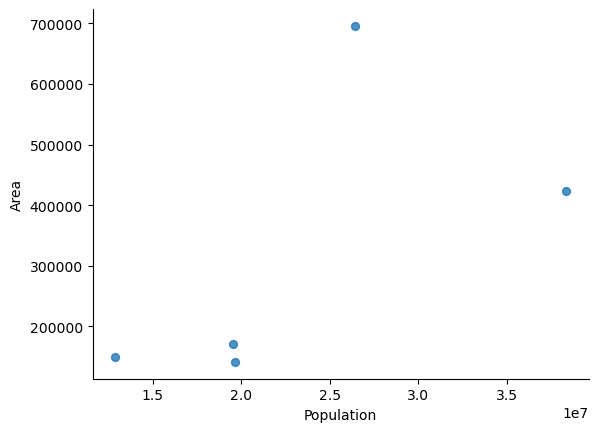

In [123]:
# @title Population vs Area

from matplotlib import pyplot as plt
states.plot(kind='scatter', x='Population', y='Area', s=32, alpha=.8)
plt.gca().spines[['top', 'right',]].set_visible(False)

You may access columns directly with names, *then* you can access individuals with their index.

In [40]:
states['Area']

California    423967
Texas         695662
New York      141297
Florida       170312
Illinois      149995
Name: Area, dtype: int64

In [41]:
states['Area']['Texas']

695662

To ease the access, Pandas offers dedicated methods:
* <tt>iloc</tt> enables to access subparts of the dataframe as if it was a NumPy array.

In [42]:
states.iloc[:2]

,Population,Area
California,38332521,423967
Texas,26448193,695662


In [43]:
states.iloc[:2,0]

California    38332521
Texas         26448193
Name: Population, dtype: int64

* <tt>loc</tt> does the same but with the explicit names (the last one is included)

In [44]:
states.loc[:'New York']

,Population,Area
California,38332521,423967
Texas,26448193,695662
New York,19651127,141297


In [45]:
states.loc[:,'Population':]

,Population,Area
California,38332521,423967
Texas,26448193,695662
New York,19651127,141297
Florida,19552860,170312
Illinois,12882135,149995


## Questions and Exercises

**1. Series:**
   - Create a Pandas Series with the following data: [10, 20, 30, 40, 50].
   - Access the third element of the Series.
   - What is the data type of the Series?

**2. DataFrames:**
   - Create a Pandas DataFrame with two columns: 'Name' and 'Age'.
   - Add three rows to the DataFrame with the following data:
     - Name: 'Alice', Age: 25
     - Name: 'Bob', Age: 30
     - Name: 'Charlie', Age: 35
   - Access the 'Age' column of the DataFrame.
   - What is the shape of the DataFrame?

**3. Indexing:**
   - Using the DataFrame from question 2, access the row with the name 'Bob' using `loc`.
   - Access the age of 'Alice' using `iloc`.

**4. File I/O:**
   - Read the 'president_heights.csv' file into a DataFrame.
   - What is the average height of the presidents?
   - What is the name of the tallest president?

**5. Advanced:**
   - Create a DataFrame with three columns: 'A', 'B', and 'C'.
   - Fill the DataFrame with random numbers.
   - Calculate the mean of each column.
   - Add a new column 'D' which is the sum of columns 'A' and 'B'.
   - Sort the DataFrame by column 'D' in descending order.

In [52]:
#Series:

#Create a Pandas Series with the following data: [10, 20, 30, 40, 50].
numbers=pd.Series([10,20,30,40,50])
print(numbers)

#Access the third element of the Series.
print("\nthird element: ",numbers.iloc[2])

#What is the data type of the Series?
print(type(numbers))

0    10
1    20
2    30
3    40
4    50
dtype: int64

third element:  30
<class 'pandas.core.series.Series'>


In [64]:
#Create a Pandas DataFrame with two columns: 'Name' and 'Age'.
person=pd.DataFrame({"Name":["Hania","Maria","Laiba"],"Age":[20,25,22]})
print(person)
print("\n")
#Add three rows to the DataFrame with the following data:
#Name: 'Alice', Age: 25
#Name: 'Bob', Age: 30
#Name: 'Charlie', Age: 35
new_rows = pd.DataFrame({"Name":["Alice","Bob","Charlie"],"Age":[25,30,35]})
person= pd.concat([person, new_rows], ignore_index=True)
print(person)
print("\n")

#Access the 'Age' column of the DataFrame.
print(person["Age"],"\n")

#What is the shape of the DataFrame?
print(person.shape)

    Name  Age
0  Hania   20
1  Maria   25
2  Laiba   22


      Name  Age
0    Hania   20
1    Maria   25
2    Laiba   22
3    Alice   25
4      Bob   30
5  Charlie   35


0    20
1    25
2    22
3    25
4    30
5    35
Name: Age, dtype: int64 

(6, 2)


In [73]:
#Indexing:

#Using the DataFrame from question 2, access the row with the name 'Bob' using loc.
bob_row = person.loc[person["Name"] == "Bob"]
print(bob_row)

#Access the age of 'Alice' using iloc.
alice_age=person.iloc[3,1]
print("\nAlice age:", alice_age)

  Name  Age
4  Bob   30

Alice age: 25


In [74]:
#File I/O:

#Read the 'president_heights.csv' file into a DataFrame.
df=pd.read_csv('president_heights.csv')
df

,order,name,height(cm)
0,1,George Washington,189
1,2,John Adams,170
2,3,Thomas Jefferson,189
3,4,James Madison,163
4,5,James Monroe,183
5,6,John Quincy Adams,171
6,7,Andrew Jackson,185
7,8,Martin Van Buren,168
8,9,William Henry Harrison,173
9,10,John Tyler,183


In [82]:
#What is the average height of the presidents?
avg_height=df["height(cm)"].mean()
print("average height: ",avg_height)
#What is the name of the tallest president?
tallest= df.loc[df["height(cm)"].idxmax(), "name"]
print("tallest president: ", tallest)

average height:  179.93023255813952
tallest president:  Abraham Lincoln


In [94]:
#Advanced:

#Create a DataFrame with three columns: 'A', 'B', and 'C'.
#Fill the DataFrame with random numbers.
data = pd.DataFrame({
    'A': np.random.randn(5),
    'B': np.random.randn(5),
    'C': np.random.randn(5)
})
print(data)
#Calculate the mean of each column.
print("\nmean:\n",data.mean())
#Add a new column 'D' which is the sum of columns 'A' and 'B'.
data["D"] = data["A"] + data["B"]
print(data)
print("\n")
#Sort the DataFrame by column 'D' in descending order.
sorted=data.sort_values("D", ascending=False)
print(sorted)

          A         B         C
0 -1.161993 -0.103203  0.128110
1 -0.861845  0.002754 -1.402631
2 -0.973859 -1.530717 -1.011105
3  0.585455  0.090920  0.888478
4  1.829667 -0.613971  0.229679

mean:
 A   -0.116515
B   -0.430843
C   -0.233494
dtype: float64
          A         B         C         D
0 -1.161993 -0.103203  0.128110 -1.265195
1 -0.861845  0.002754 -1.402631 -0.859091
2 -0.973859 -1.530717 -1.011105 -2.504576
3  0.585455  0.090920  0.888478  0.676375
4  1.829667 -0.613971  0.229679  1.215697


          A         B         C         D
4  1.829667 -0.613971  0.229679  1.215697
3  0.585455  0.090920  0.888478  0.676375
1 -0.861845  0.002754 -1.402631 -0.859091
0 -1.161993 -0.103203  0.128110 -1.265195
2 -0.973859 -1.530717 -1.011105 -2.504576
